# **Problem Statement**

###  **Machine Failure Prediction Using Machine Learning for Predictive Maintenance**


In industrial environments, unexpected machine failures can lead to production downtime, increased operational costs, and safety risks. Traditional maintenance strategies such as reactive maintenance (repair after failure) or scheduled maintenance (fixed time intervals) are inefficient and costly.
The objective of this project is to develop a machine learning classification model that can predict whether a machine is likely to fail or not .

---

## **1. Importing Libraries**

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [101]:
from sklearn.metrics import(
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report
)

In [133]:
from imblearn.over_sampling import SMOTE  # for handling class imbalance

## **2. Load Dataset**

In [29]:
data = pd.read_csv('/content/predictive_maintenance_dataset.csv')
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## **3. Data Cleaning**

In [30]:
data = data.drop(columns=[
    'UDI',
    'Product ID',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
])

- These columns represent failure types, indicating why machine failed i.e. reason behind the failure and not whether it failed.

## **4. Dataset Shape and Class Distribution**

In [137]:
print("Dataset shape: ",X.shape)
print("Classes: ",np.unique(y))

print("\nClass Distribution:")  # This shows how many failures vs non-failures we have
print("Number of samples\n",y.value_counts()) # number of samples in each class
print("\nPercentage\n",y.value_counts(normalize=True) * 100) # percentage of each class

Dataset shape:  (2000, 7)
Classes:  [0 1]

Class Distribution:
Number of samples
 Machine failure
0    9661
1     339
Name: count, dtype: int64

Percentage
 Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


- Class distribution helps us understand the imbalance present in the target variable.

## **5. Encoding Categorical Column**

In [38]:
X = pd.get_dummies(X, columns=["Type"], drop_first=True)  # To convert categorical features into numerical format

 - Encoding is required to convert categorical variables into numerical format, as machine learning models can only process numerical data.

## **6. Defining Features and Target Variables**

In [42]:
X = data.drop('Machine failure',axis=1)
y = data["Machine failure"]
data.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


- The dataset is divided into input features (X) and target variables (y), where 'Machine failure' is the final prediction

## **7. Train-Test Split**

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **8. Feature Scaling**

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- Important for Logistic Regression and SVM

## **9. Handling Class Imbalance Using SMOTE**

- SMOTE is used to improve model performance on imbalanced data by creating synthetic class samples

### **For Scaled Data**





In [132]:
smote = SMOTE(random_state=42)
X_train_smote_scaled, y_train_smote_scaled = smote.fit_resample(
    X_train_scaled, y_train
)

- This is used for Logistic Regression and SVM

### **For Unscaled Data**

In [47]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

- This is used for Decision Tree and Random Forest

## **10. Model Training**

### **1. Logistic Regression**

In [72]:
# Model Training
lr_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    C=1.0,
    max_iter=1000,
)

In [73]:
lr_model.fit(X_train_smote_scaled, y_train_smote_scaled)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [74]:
# Prediction
y_pred_lr = lr_model.predict(X_test_scaled)

In [138]:
# Probability
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

### **2. Support Vector Machine (SVM)**

In [76]:
# Model Training
svm_model = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced', probability=True)
svm_model.fit(X_train_smote_scaled, y_train_smote_scaled)

SVC(C=1, class_weight='balanced', probability=True)

In [77]:
# Prediction
y_pred_svm = svm_model.predict(X_test_scaled)

In [139]:
# Probability
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

### **3. Decision Tree**

In [88]:
# Model Training
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    class_weight = 'balanced',
    random_state=42
    )

In [89]:
dt_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [90]:
# Prediction
y_pred_dt = dt_model.predict(X_test)

In [140]:
# Probability
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

### **4. Random Forest**

In [83]:
# Model Training
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

In [84]:
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [85]:
# Prediction
y_pred_rf = rf_model.predict(X_test)

In [142]:
# Probability
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

## **11. Model Evaluation and Visualization**

In [99]:
def evaluate_model(name, y_test, y_pred, y_prob):
  print(f"\n{name} Evaluation\n")
  print("\nConfusion Matrix:\n",confusion_matrix(y_test, y_pred))
  print("\nClassification Report:\n",classification_report(y_test, y_pred))
  print("ROC-AUC Score: ",roc_auc_score(y_test, y_prob))
  print("\n")

In [100]:
evaluate_model("Logistic Regression:",y_test, y_pred_lr, y_prob_lr)
evaluate_model("SVM:",y_test, y_pred_svm, y_prob_svm)
evaluate_model("Decision Tree:",y_test, y_pred_dt, y_prob_dt)
evaluate_model("Random Forest:",y_test, y_pred_rf, y_prob_rf)


Logistic Regression: Evaluation


Confusion Matrix:
 [[1603  329]
 [  12   56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.15      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000

ROC-AUC Score:  0.9078294361222751



SVM: Evaluation


Confusion Matrix:
 [[1776  156]
 [   7   61]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96      1932
           1       0.28      0.90      0.43        68

    accuracy                           0.92      2000
   macro avg       0.64      0.91      0.69      2000
weighted avg       0.97      0.92      0.94      2000

ROC-AUC Score:  0.9599926927292657



Decision Tree: Evaluation


Confusion Matrix:
 [[1853   79]
 [  25   43]]



### **ROC-AUC Curve**

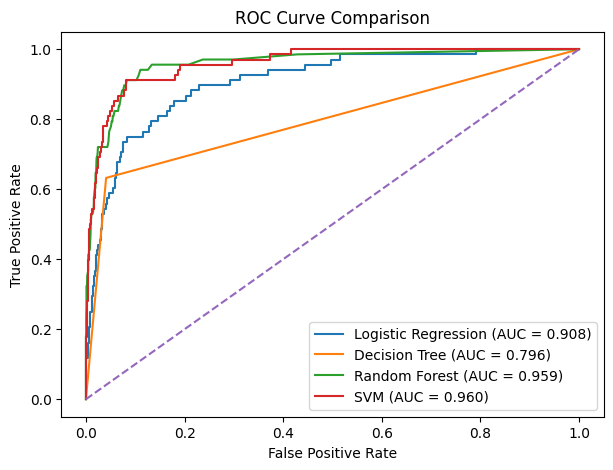

In [108]:
plt.figure(figsize=(7,5))

probs = {
    "Logistic Regression": y_prob_lr,
    "Decision Tree": y_prob_dt,
    "Random Forest": y_prob_rf,
    "SVM": y_prob_svm
}

for name, y_prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob) # fpr for false positive rate and, tpr for true positive rates
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


- The ROC-AUC curve is plotted to evaluate how well a model can distinguish between machines that will fail and those that will not, independent of the classification threshold.

### **Feature Importance (Random Forest)**

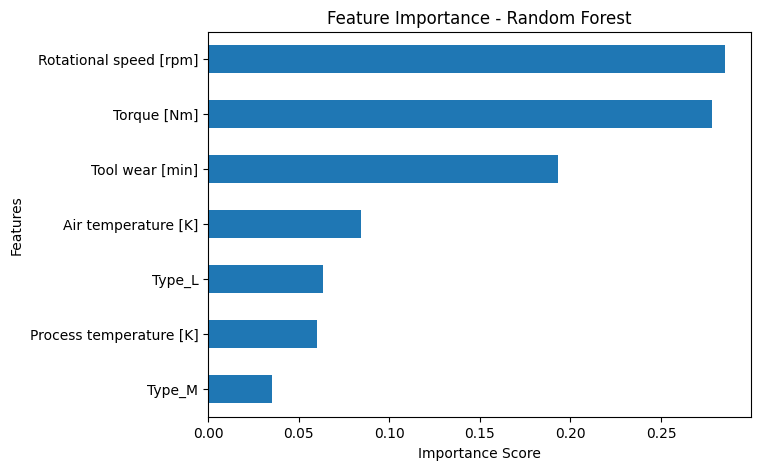

In [146]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_smote.columns
).sort_values(ascending=True)   # ascending for horizontal plot

# plot graph
plt.figure(figsize=(7,5))
feature_importance.plot(kind='barh')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")
plt.show()


- Feature importance helps to identify which variables contribute the most to predicting machine failure.

## **12. Comparison of Models**

In [129]:
def comparison_table(y_test, y_pred, y_prob):
    return {
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC Score": roc_auc_score(y_test, y_prob),
    }

In [130]:
results = {
    "Logistic Regression": comparison_table(y_test, y_pred_lr, y_prob_lr),
    "SVM": comparison_table(y_test, y_pred_svm, y_prob_svm),
    "Decision Tree": comparison_table(y_test, y_pred_dt, y_prob_dt),
    "Random Forest": comparison_table(y_test, y_pred_rf, y_prob_rf),
}

In [131]:
comparison_df = pd.DataFrame(results).T
comparison_df

,Recall,Precision,F1 Score,ROC-AUC Score
Logistic Regression,0.823529,0.145455,0.247241,0.907829
SVM,0.897059,0.281106,0.428070,0.959993
Decision Tree,0.632353,0.352459,0.452632,0.795731
Random Forest,0.720588,0.466667,0.566474,0.959133


- Although SVM achieved the highest recall, Random Forest provided the
best balance between recall and precision, resulting in the highest F1 score. Therefore, Random Forest is best to use for machine failure prediction.


## **13. Final Predictions**

### **1. Predictions on Test Data**

In [147]:
# predictions on test set
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# creating dataframe to view predictions
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf,
    "Probability": y_prob_rf
})

predictions_df.head()


,Actual,Predicted,Probability
2997,0,1,0.76
4871,0,0,0.00
3858,0,0,0.47
951,0,0,0.00
6463,0,0,0.14


### **2. Testing Model on a Single Sample**

In [149]:
# select one sample from test set
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)[0]
probability = rf_model.predict_proba(sample)[0][1]

print("Prediction:", prediction)
print("Failure Probability:", probability)

Prediction: 1
Failure Probability: 0.76


### **3. Failed Predictions**

In [151]:
# finding incorrect predictions
errors = predictions_df[predictions_df["Actual"] != predictions_df["Predicted"]]

print("Number of misclassified samples:", len(errors))
errors.head()


Number of misclassified samples: 75


,Actual,Predicted,Probability
2997,0,1,0.76
4851,1,0,0.23
3104,0,1,0.55
4632,1,0,0.37
5821,0,1,0.71


- Predictions were made on the test data to see how the model performs on new, unseen data.
- A prediction on a single sample was done to show how the model would work in a real-life situation.
- The wrongly predicted cases were studied to understand where the model makes mistakes and how it can be improved.

## **14. Conclusion**

- Random Forest was selected as the final model because it achieved the best balance between recall and precision, resulting in the highest F1 score while maintaining a high ROC-AUC. Its ability to capture complex patterns and reduce overfitting makes it well-suited for machine failure prediction.